## Mapping Corporate Ethics: Clustering UK Companies' Values Using NLP

Author: Johannes Van Cauwenberghe

Institution: University of London

In [4]:
from pathlib import Path
from typing import Union
import requests, gzip, os, json
from typing import Iterator, Generator
from tqdm.notebook import tqdm

from pyspark.sql import SparkSession, DataFrame, Row, Window
from pyspark.sql.functions import split, regexp_extract, col, regexp_replace, desc, lower, count
from pyspark.sql.types import StringType, FloatType

import pyspark.ml.feature as ft
from pyspark.ml.clustering import KMeans, BisectingKMeans, LDA
from pyspark.ml.evaluation import ClusteringEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline, PipelineModel
from sklearn.datasets import fetch_20newsgroups
from pyspark.ml.classification import NaiveBayes

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [35]:
# Create a session
spark = SparkSession\
    .builder\
    .appName("CC")\
    .config("spark.sql.repl.eagerEval.enabled", True) \
    .getOrCreate()

# Create a reference to sparkContext 
sc = spark.sparkContext

## Index

The notebook has the following structure:

- [**1. Data Extraction**](#**1-data-extraction**)
  - [1.1 Generic Helper Functions](#1.1-generic-helper-functions)
  - [1.2 Downloading a Subset of CC-Index Files](#1.2-downloading-a-subset-of-cc-index-files)
  - [1.3 Summary of Interactive Exploratory Data Analysis and Preprocessing of CC-Index Files](#1.3-summary-of-interactive-exploratory-data-analysis-and-preprocessing-of-cc-index-files)
  - [1.4 Selection of URL Segments and Ordering by Count](#1.4-selection-of-url-segments-and-ordering-by-count)
  - [1.5 Processing WET Files](#1.5-downloading-wet-files)
- [**2. Data Preprocessing**](#**2-data-preprocessing**)
- [**3. Natural Language Processing**](#**3-natural-language-processing**)
  - [3.1 Classifier](#3.1-classifier)
    - [3.1.1 Training the Classifier](#3.1.1-training-the-classifier)
    - [3.1.2 Evaluating the Classifier](#3.1.2-evaluating-the-classifier)
    - [3.1.3 Implementing the Trained Classifier](#3.1.3-implementing-the-trained-classifier)
  - [3.2 Clustering](#3.2-clustering)
    - [3.2.1 Fitting K-Means](#3.2.1-fitting-k-means)
    - [3.2.2 Evaluating the Clusters](#3.2.2-evaluating-the-clusters)
    - [3.2.3 *Inspecting the Clusters*](#3.2.3-*inspecting-the-clusters*)

## **1. Data Extraction**

Before diving into the code, it is recommended to review the accompanying documentation, particularly the section "Data Structure and Summary of Exploratory Analysis," which outlines the motivations behind the approach taken here. As this notebook was created on Lena, all paths point to HDFS and are specified in the code. Additionally, in order to test the code it is advised to test on a subset. This can easily be achieved by setting the `MARKER` below. 


In [3]:
"""
---------------------------------------
|            IMPORTANT                |
|   Set MARKER to True to run subset  |
---------------------------------------
"""

MARKER = False

### 1.1 Generic Helper Functions

In this initial section, we:
- Define global variables `BASE_URL` and `LOCAL_DIR`.
- Develop generic functions for downloading files to the local node and HDFS.

In [181]:
BASE_URL = f'https://data.commoncrawl.org/'
LOCAL_DIR = './cc_data/'

In [178]:
def download_to_local(file_path: Union[str, Path]) -> Path:
    """
    Downloads a file to the specified local path, with a progress bar using tqdm.

    :param file_path: The local path where the file will be saved. This can be a string or a Path object.
    :return: The path to the downloaded file.
    :raises IOError: If the file cannot be saved to the specified location.
    """
    with requests.get(BASE_URL + file_path, stream=True) as r:
        r.raise_for_status()
        total_size = int(r.headers.get('content-length', 0)) # sets total
        block_size = 1024
        tqdm_bar = tqdm(total=total_size, unit='iB', unit_scale=True)    

        local_path = Path(LOCAL_DIR) / file_path.split('/')[-1]

        with open(local_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=block_size):
                if chunk: 
                    tqdm_bar.update(len(chunk))
                    f.write(chunk)
                    
        tqdm_bar.close()
        
        return local_path

def download_to_hdfs(file_path: Union[str, Path]) -> Path: 
    """
    Downloads a file to the local system, moves it to HDFS, and returns the HDFS path.

    :param file_path: The path of the file to download.
    :return: The HDFS path where the file is stored. This starts with hdfs:///user/jcauw001/cc_data/.
    :raises IOError: If the file cannot be saved to the specified location.
    """
    
    local_path = download_to_local(file_path)
       
    os.system(f"hadoop fs -moveFromLocal -f {local_path} ./cc_data")
    
    hdfs_path = f"hdfs:///user/jcauw001/cc_data/{local_path.name}"

    return hdfs_path

### 1.2 Downloading a Subset of CC-Index Files

We proceed by downloading a subset of the index files:

1. Define a global variable `aug_2024` pointing to the relevant URL pattern in the index files.
2. Download the overview of the index files (`cluster_idx`), which contains the first line of each index file.
3. Filter for `co.uk` domains and add the corresponding index files to HDFS for analysis.

In [49]:
aug_2024 = r'cc-index/collections/CC-MAIN-2024-33/indexes'

In [ ]:
# Download index of the index 
cluster_idx = download_to_local(aug_2024 + "/cluster.idx")

In [179]:
def download_uk_index_files(crawl_date: str) -> None:
    """
    Downloads index files for the specified crawl date, processes UK-specific data, and stores the files in HDFS.

    This function reads a cluster index file, filters for UK-specific data, and then downloads the corresponding 
    index files to the local system. After downloading, the files are moved to HDFS, and their HDFS paths are printed.
    
    :param crawl_date: The crawl date used to locate the index files. This should be in the format of 'YYYY-MM-DD'.

    :raises IOError: If there is an error in reading the cluster index file or saving files to HDFS.
    """    
    with open(cluster_idx, 'rt', encoding='utf-8') as f:
        cluster_idx = [line.strip() for line in f]

    uk_cdx = {(i.rsplit('\t', 4)[1]) for i in cluster_idx if i.startswith('uk,co')}


    for uk in uk_cdx:
        full_path = os.path.join(crawl_date, uk)
        hdfs_path = download_to_hdfs(full_path)
        
        print(hdfs_path)

In [ ]:
# This downloads the index files to HDFS, as shown below
# download_uk_index_files(aug_2024)

Index files can be found on HDFS:

In [13]:
!hadoop fs -ls cc_data/

Found 5 items
-rw-r--r--   3 jcauw001 users  909769509 2024-08-22 15:54 cc_data/cdx-00290.gz
-rw-r--r--   3 jcauw001 users  766163875 2024-08-22 15:54 cc_data/cdx-00291.gz
-rw-r--r--   3 jcauw001 users  752662267 2024-08-22 15:55 cc_data/cdx-00292.gz
-rw-r--r--   3 jcauw001 users  679284971 2024-08-22 15:56 cc_data/cdx-00293.gz
-rw-r--r--   3 jcauw001 users  717188547 2024-08-22 15:56 cc_data/cdx-00294.gz


### 1.3 Summary of Interactive Exploratory Data Analysis and Preprocessing of CC-Index Files

Here we process the index files to select only the references to the target documents. We will do this in these steps:

- Extract and process index data from the cdx files.
- Construct a DataFrame of large domains.
- Read compressed cdx files from HDFS, filter records related to `.co.uk` domains, and create a Spark DataFrame (`large_domains_df`) containing large domains with more than five pages.
- Collect insights such as the total number of URLs ending with `.co.uk`, the number of unique domains found, and the number of single-page and large domains.

In [ ]:
# If MARKER is set to False ~23 minutes
# If True ~3 minutes
csr_index = r"csr_index.parquet"

hdfs_paths = r"cc_data/cdx-0029[0-4]*.gz"

partitions = 60

if MARKER:
    hdfs_paths = r"cc_data/cdx-00291.gz"
    partitions = 5

# extract gzip files, then partition (avoid pickling errors) 
text_index=sc.textFile(hdfs_paths).repartition(partitions)

# Transform the data to JSON strings 
# See "The Structure of the Data" for more information
json_str=text_index.filter(lambda x: x.startswith('uk,co')).map(lambda x: '{' + x.rsplit('{')[1])

# Read the JSON strings into a DataFrame
master_index=spark.read.json(json_str).cache()

# Count the total number of URLs ending with `.co.uk` (for print)
urls_ending_co_uk=master_index.count()

# Filter the DataFrame based on specific criteria and extract the domain
domains_df = master_index \
    .filter('charset == "UTF-8" and status == "200" and languages == "eng"') \
    .select(['*', regexp_extract(master_index.url, r'([0-9a-z\.-]+)\.uk', 0).alias('domain')]) \
    .select(['filename', 'url', 'domain'])  # Drop most of the 130 columns

We now perform a filtering operation in 3 steps:

In [147]:
# 1. Group by domain and count occurrences to identify large domains
count_domains_df = domains_df \
    .groupBy('domain').count() \
    .orderBy(desc('count'))

# Count the number of distinct domains as well as domains with only one page
unique_domains = count_domains_df.count()
single_domains = count_domains_df.filter('count == 1').count()
        

# 2. Filter for domains with more than 5 pages
large_domain_idx = count_domains_df.filter('count > 5').select(['domain', 'count'])

# Cache to speed up subsequent operations and count domains with over 5 pages
large_domain_idx.cache()
large_domains = large_domain_idx.count()


# 3. Rejoin the domains to apply `count > 5` filter
large_domains_df = domains_df.join(large_domain_idx, on='domain')  # inner join is the default

# Note that this groupBy => join operation can be solved with a window function
# See 1.4 for an example
   

print(f"There are {urls_ending_co_uk} URLs ending with co.uk.\n",
        f"There are {unique_domains} unique domains in the `.co.uk` second-level domain.\n",
        f"Of these unique domains, there are {single_domains} domains with only one page.\n",
        f"There are {large_domains} large domains.")

There are 45127115 URLs ending with co.uk.
 There are 806588 unique domains in the `.co.uk` second-level domain.
 Of these unique domains, there are 190182 domains with only one page.
 There are 423813 large domains.


In [150]:
# Count the pages corresponding to the large domains (= over 5 pages per domain)
large_domains_df.count()

33911119

In [3]:
# This is now available in memory
# Use this to free-up resources
large_domain_idx.unpersist()     
large_domains_df.unpersist()

### 1.4 Selection of URL Segments and Ordering by Count

Here, the `large_domains_df` DataFrame is refined to focus on URL paths with specific keywords. Additionally,
- Paths are adjusted to reference WET files instead of WARC files. (We lose the ability to specify bytestring offset and length, however. See Project Proposal.)
- The DataFrame is then ranked by the count of occurrences of each `wet_filename` using a window function and ordered by `domain_count` in descending order.

In [169]:
# Filter the `url` column for relevant URL segments 
# And add those segments as a separate column
master_df = large_domains_df\
    .filter(
        col('url').rlike(r'/about(-us)?$/|/(our-)?mission$|/(our-)?vision/|/(our-)?values$|purpose$|strategy$|\bcsr\b|\besg\b'))\
            .select(['*', 
                     regexp_extract(
                         col('url'), r'(about|mission|vision|values|purpose|strategy|csr|esg)', 0)
                         .alias('csr_segment')
                         ])

# Rewrite the warc paths as WET paths and add them a `wet_filename` column
# This conveniently does both sections in one stroke
master_df_WET = master_df\
    .select(['*', 
             regexp_replace(
                 regexp_replace(col('filename'), r'/warc/', r'/wet/'), r'\.warc\.gz', r'\.warc\.wet\.gz')\
                    .alias('wet_filename')
                    ]) 


# Sort by domain_count and add ``domain_count`` as a column
# First, create a window_spec
window_spec = Window.partitionBy('filename')

# Then, apply the window function 
master_df_wet_with_count = master_df_WET.withColumn('domain_count', count('wet_filename').over(window_spec))

ordered_df = master_df_wet_with_count.orderBy(desc('domain_count'))

ordered_df.cache()

domain,filename,url,count,csr_segment,wet_filename,domain_count
rotec-catalogue.c...,crawl-data/CC-MAI...,https://rotec-cat...,788,purpose,crawl-data/CC-MAI...,4
www.hawesandco.co.uk,crawl-data/CC-MAI...,https://www.hawes...,184,strategy,crawl-data/CC-MAI...,4
www.peterlawson.c...,crawl-data/CC-MAI...,https://www.peter...,54,strategy,crawl-data/CC-MAI...,4
www.wealthatwork....,crawl-data/CC-MAI...,https://www.wealt...,161,esg,crawl-data/CC-MAI...,4
www.westgrove.co.uk,crawl-data/CC-MAI...,https://www.westg...,155,esg,crawl-data/CC-MAI...,3
www.westgrove.co.uk,crawl-data/CC-MAI...,https://www.westg...,155,esg,crawl-data/CC-MAI...,3
www.rbs.co.uk,crawl-data/CC-MAI...,https://www.rbs.c...,1191,esg,crawl-data/CC-MAI...,3
craftycounsel.co.uk,crawl-data/CC-MAI...,https://craftycou...,196,esg,crawl-data/CC-MAI...,3
www.davisbonley.c...,crawl-data/CC-MAI...,https://www.davis...,73,strategy,crawl-data/CC-MAI...,3
chandlersca.co.uk,crawl-data/CC-MAI...,https://chandlers...,91,esg,crawl-data/CC-MAI...,3


In [170]:
# Inspect (selected columns)
ordered_df.select(['url', 'csr_segment', 'domain_count']).show(truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------+-----------+------------+
|url                                                                                                                                               |csr_segment|domain_count|
+--------------------------------------------------------------------------------------------------------------------------------------------------+-----------+------------+
|https://rotec-catalogue.co.uk/product/hydraulic-spill-absorbent-clay-general-purpose                                                              |purpose    |4           |
|https://www.hawesandco.co.uk/blog/property-maintenance-strategy                                                                                   |strategy   |4           |
|https://www.peterlawson.co.uk/resources/your-business/developing-your-business/business-processes/is-outsourcing-the-best-strateg

In [157]:
ordered_df.count()

7951

In [171]:
# Investment 'spec sheets' polute our dataset
ordered_df_ = ordered_df.filter(~col('url').rlike(r'shares|fund|bank|invest'))
ordered_df_.count()

6946

In [172]:
# Avoiding rework, we save.
csr_index = r"csr_index.parquet" # as defined above

if not MARKER:
    ordered_df.write.save(csr_index, mode='overwrite')

# Release resources
ordered_df.unpersist()

domain,filename,url,count,csr_segment,wet_filename,domain_count
rotec-catalogue.c...,crawl-data/CC-MAI...,https://rotec-cat...,788,purpose,crawl-data/CC-MAI...,4
www.peterlawson.c...,crawl-data/CC-MAI...,https://www.peter...,54,strategy,crawl-data/CC-MAI...,4
www.wealthatwork....,crawl-data/CC-MAI...,https://www.wealt...,161,esg,crawl-data/CC-MAI...,4
www.hawesandco.co.uk,crawl-data/CC-MAI...,https://www.hawes...,184,strategy,crawl-data/CC-MAI...,4
www.thistleinitia...,crawl-data/CC-MAI...,https://www.thist...,296,about,crawl-data/CC-MAI...,3
y5vae.trade.www.l...,crawl-data/CC-MAI...,https://y5vae.tra...,6185,esg,crawl-data/CC-MAI...,3
www.investmentwee...,crawl-data/CC-MAI...,https://www.inves...,2541,esg,crawl-data/CC-MAI...,3
www.westgrove.co.uk,crawl-data/CC-MAI...,https://www.westg...,155,esg,crawl-data/CC-MAI...,3
www.londoncomplia...,crawl-data/CC-MAI...,https://www.londo...,17,esg,crawl-data/CC-MAI...,3
chandlersca.co.uk,crawl-data/CC-MAI...,https://chandlers...,91,esg,crawl-data/CC-MAI...,3


### 1.5 Processing WET Files

We can now download the textual data from the top WET files. We target documents that correspond to the highest number of URLs. This is an imperfect solution; see the Topic Proposal for context.

The process includes:

1. Downloading the top WET files and determining their HDFS paths.
2. Processing and filtering the content using `read_wet_file_local()` (taking some inspiration from [code examples](https://groups.google.com/g/common-crawl/c/xTER7EJ5kuc)).
3. Consolidating the results into a final DataFrame (`final_filtered_df`).


In [173]:
csr_index = r"csr_index.parquet"
new_df = spark.read.load(csr_index).cache()

In [175]:
# If MARKER is set to False ~8 minutes
# If True creates a subset (and overwrites the outputs)
SAMPLE_SIZE = 300 
if MARKER:          
    SAMPLE_SIZE = 100   

In [176]:
def process_record(iterator: Iterator[Row]) -> Generator[Row, None, None]:
    """
    Processes an iterator of WET file records, extracting relevant content and metadata.

    This processes each record from a WET file, filtering and extracting the target URI and content. 
    It skips lines that are part of the WARC headers or that are too short (e.g., menu items or other short content).
    Only records with content longer than 500 characters are yielded, to ensure only substantial content is processed.

    :params iterator: Iterates over rows of a WET file, where each row represents a line in the file.
    :yields: A PySpark Row object with the following fields:
            - 'WARC-Target-URI' (str): The target URI extracted from the WET file headers.
            - 'content' (str): The extracted content of the webpage, concatenated from all relevant lines.
    """
    record = {}
    content_lines = []
    
    # Iterate over over the Rows
    for row in iterator:        
        line = row.value
        line = line.strip()

        # Skip Content metadata
        if line.startswith('Content-'):
            continue
        
        # Split by `WARC/1.0` header
        if line.startswith('WARC/1.0'):
            if record:
                record['content'] = "\n".join(content_lines)
                
                # Skip short pages
                if len(record['content']) > 500:

                    # Unpack dict in a Row object
                    yield Row(**{
                        'WARC-Target-URI': record.get('WARC-Target-URI', ''),
                        'content': record.get('content', '')
                    })

            record = {}
            content_lines = []

        # Get all the WARC metadata (`WARC-Target-URI`)
        elif line.startswith('WARC-'):
            parts = line.split(': ', 1)
            if len(parts) == 2:
                key, value = parts
                record[key] = value.strip()
        
        # Skip short lines (typically menu items)
        elif len(line) < 50:
            continue

        else:
            content_lines.append(line)
    
    if 'WARC-Target-URI' in record and content_lines:
        record['content'] = "\n".join(content_lines)

        # Skip short pages
        if len(record['content']) > 500:

            # Unpack dict in a Row object
            yield Row(**{
                'WARC-Target-URI': record.get('WARC-Target-URI', ''),
                'content': record.get('content', '')
                        })

def read_wet_file_local(wet_path: str, new_df: DataFrame) -> DataFrame:
    """
    Reads and processes a local WET file, filtering and joining content with a provided DataFrame.

    This reads a WET file from the specified path, processes it using the `process_record` function,
    and then joins the resulting DataFrame with another DataFrame (`new_df`) based on the 'WARC-Target-URI'.
    The final result is a DataFrame with selected columns, including the 'url' and 'content'.

    wet_path: The local path to the WET file to be processed.
    :param new_df: A PySpark DataFrame containing URLs that will be joined with the processed WET file data.

    :return: A PySpark DataFrame containing the joined results, with columns:
            - 'url': The URL from the WET file, renamed from 'WARC-Target-URI'.
            - 'content': The content extracted from the WET file.
    """
    wet_rdd = spark.read.text(wet_path).rdd
    wet_df = wet_rdd.mapPartitions(process_record).toDF()
    
    wet_df = wet_df.select('WARC-Target-URI', 'content')

    # Again an inner join with the new_df based on the 'WARC-Target-URI'
    joined_df = wet_df.join(new_df, wet_df['WARC-Target-URI'] == new_df.url) \
                        .select(col('WARC-Target-URI').alias('url'), 'content')
    
    return joined_df

def check_hdfs_and_download(row: Row) -> str:
    """
    Returns the path on HDFS for each `row` of the index.
    
    The function first performs a check if the file exists on HDFS.
    It downloads the file if it does not exist.

    :param row: A row in the index.
    :return: The path to the file on HDFS. 
    """
    wet_filename = row['wet_filename'].split('/')[-1].strip()
    
    wet_path = "hdfs:///user/jcauw001/cc_data/" + wet_filename

    # Check the file exists before downloading
    if os.system(f"hadoop fs -test -e {wet_path}") != 0:
        wet_path = download_to_hdfs(row['wet_filename'])        
    
    return wet_path


def process_WET(df: DataFrame) -> list:
    """
    Process WET files, as limited by global `SAMPLE_SIZE`.

    :param df: The DataFrame containing the index.
    :return: A list of DataFrames containing the content of WET files.
    
    """
    # Reorder
    df = df.orderBy(desc('domain_count'))

    # Iterate over rows
    filtered_df_list = []
    for row in df.limit(SAMPLE_SIZE).collect(): 

        # Check if it's already HDFS 
        wet_path = check_hdfs_and_download(row)

        # Process WET file
        filtered_df = read_wet_file_local(wet_path, df)

        # Append to list
        filtered_df_list.append(filtered_df)

    return filtered_df_list

In [ ]:
# Takes ~8 minutes unless the MARKER is set to False, else ~3
filtered_df_list = process_WET(new_df)

In [183]:
# Union the DataFrame list
# This is slow, it takes ~15 min unless the MARKER is set, otherwise ~8 minutes
final_filtered_df = filtered_df_list[0]

for df in filtered_df_list[1:]:
    final_filtered_df = final_filtered_df.union(df)

final_filtered_df = final_filtered_df.distinct()
final_filtered_df.cache()
final_filtered_df.count()

269

In [184]:
# Overwrite or continue with ``preprocessed``
if not MARKER:
    final_filtered_df.write.save("preprocessed.parquet", mode='overwrite')

In [185]:
final_filtered_df.unpersist()

url,content
https://www.hl.co...,Legal & General F...
https://www.inves...,Majority of fund ...
https://fullyvest...,As organizations ...
https://www.hl.co...,iShares IV Plc Sh...
https://www.norih...,Two simple monthl...
https://iomh.co.u...,CSR Policies & Su...
https://www.verdi...,CrowdStrike outag...
https://www.hl.co...,Invest In The Van...
https://www.inves...,You are currently...
https://www.hl.co...,This means our we...


## **2. Data Preprocessing**

This section focuses on preprocessing the text data for analysis (See Drabas (2017), chapter 6, part 4.). The pipeline includes tokenization, stopword removal, vectorization with `CountVectorizer`, and TF-IDF transformation:

1. **Tokenizer:** Splits input text into individual words (tokens).
2. **StopWordsRemover:** Eliminates common stopwords to reduce noise.
3. **CountVectorizer:** Converts filtered tokens into a vector of token counts, limited to the top 1,000 terms (`vocabSize=1000` and `minDF=10`).
4. **IDF:** Transforms frequency vectors into TF-IDF features to highlight informative terms.
5. **Pipeline:** Organizes the preprocessing steps, ensuring the text data is prepared for subsequent analysis.

In [7]:
cluster_df = spark.read.load("preprocessed.parquet").cache()
# cluster_df.take(10)

In [8]:
# Cleaning CSS before tokenising
cluster_df = cluster_df.withColumn(
    'content',
    regexp_replace('content', r"\w*:\s*[^;]+;|<.*?>|\\n|\\t|\\r|\\'|\.[a-zA-Z0-9-_]+|#[a-zA-Z0-9-_]+|[a-zA-Z-]+:[a-zA-Z0-9#.%\-]+;?", '' 
))

cluster_df.take(10)

[Row(url='https://www.bpcpartners.co.uk/resources/your-business/developing-your-business/business-processes/is-outsourcing-the-best-strategy', content='Is outsourcing the best strategy? Cheltenham  human resources (insurance, recruitment etc); marketing; information and IT systems; and delivery.\nManagement is free to concentrate on the core business\nThe use of resources, including human resources, is streamlined and more focused\nCost savings are achieved through economies of scale\nBudgeting costs becomes more reliable in these areas because they are tied into contractual agreements.\nYour customers do not draw a distinction between the core services that you provide and the outsourced services supplied by others, so any shortcomings on the part of the contractors reflect on you.\nSome companies have also experienced dissent and demotivation within their own ranks as a result of outsourcing functions such as IT to contractors who do not share the same corporate culture and so do not

In [9]:
cluster_df.count()

269

In [10]:
# Tokenizer
tokenizer = ft.Tokenizer(inputCol="content", outputCol="words")

# Stopwords
stop_words = ft.StopWordsRemover(inputCol="words", outputCol="filtered_words")

# CountVectorizer (~HashingTF)
count_vectorizer = ft.CountVectorizer(inputCol="filtered_words", outputCol="rawFeatures", vocabSize=1000, minDF=10)

# TF-IDF
idf = ft.IDF(inputCol="rawFeatures", outputCol="features")

# Pipeline
pipeline = Pipeline(stages=[tokenizer, stop_words, count_vectorizer, idf])

In [11]:
# For improved inspection
all_stop_words = stop_words.getStopWords() + ['content-type:', 'text/plain', 'content-length:']

stop_words = stop_words.setStopWords(all_stop_words)

In [12]:
# Applied to cluster_df
pipeline_model = pipeline.fit(cluster_df)
rescaled_data = pipeline_model.transform(cluster_df)


## **3. Natural Language Processing**

### 3.1 Classifier

The URL-based filtering significantly refined our document selection, but further refinement is required. Approximately half of the remaining documents are relevant to corporate values. To improve precision, we will train a classifier for content-based filtering.

#### 3.1.1 Training the Classifier

A Multinomial Naive Bayes classifier is trained using the `fetch_20newsgroups` dataset. This lightweight classifier is suitable for text classification tasks with limited examples and aims to filter documents based on their relevance to corporate values.

In [45]:
# Load the dataset
newsgroups = fetch_20newsgroups(subset='all', shuffle=True, random_state=42, remove=('headers', 'footers'))

df = pd.DataFrame({'content': newsgroups.data,
                   'label': newsgroups.target
                   })

train_df = spark.createDataFrame(df)

# Fit the pipeline
pipeline_model = pipeline.fit(train_df)
rescaled_train_data = pipeline_model.transform(train_df)
final_train_data = rescaled_train_data.select(col("features"), col("label"))

train_data, test_data = final_train_data.randomSplit([0.8, 0.2], seed=42)

lr = NaiveBayes(featuresCol = "features",
                labelCol = "label",
                predictionCol = "prediction",
                probabilityCol = "probability",
                rawPredictionCol = "rawPrediction",
                smoothing = 0.01,
                modelType = "multinomial")

nb_clf = lr.fit(train_data)

#### 3.1.2 Evaluating the Classifier

For an insight on the classifier's performance on the `fetch_20newsgroups` test set before applying it to the broader dataset. 

In [46]:
# Make predictions on the test data
test_predictions = nb_clf.transform(test_data)

# Evaluate the model
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(test_predictions)
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.5529411764705883


#### 3.1.3 Implementing the Trained Classifier

The classifier is used to filter documents based on relevance. We identify value-related newsgroup categories and use their indices to filter the predictions. See the Topic Proposal for more information.

In [15]:
# Collect predictions for our preprocessed WET files
real_predictions = nb_clf.transform(rescaled_data)

# Housekeeping
rescaled_data.unpersist()
real_predictions.cache()

# Print a sorted list of text-based labels
predicted_labels = real_predictions.groupBy('prediction').count().collect()
classifier_preds = real_predictions.collect()

predicted_labels = sorted(predicted_labels, key=lambda key: key['count'], reverse=True)

for pred in predicted_labels:    
    print(f"we have {pred['count']} predictions for {newsgroups.target_names[int(pred.prediction)]}")

we have 50 predictions for sci.space
we have 39 predictions for sci.med
we have 33 predictions for talk.politics.mideast
we have 31 predictions for talk.politics.misc
we have 19 predictions for sci.crypt
we have 19 predictions for sci.electronics
we have 15 predictions for alt.atheism
we have 15 predictions for talk.politics.guns
we have 10 predictions for talk.religion.misc
we have 8 predictions for comp.sys.mac.hardware
we have 7 predictions for rec.motorcycles
we have 7 predictions for comp.graphics
we have 6 predictions for soc.religion.christian
we have 5 predictions for rec.autos
we have 2 predictions for comp.windows.x
we have 1 predictions for comp.sys.ibm.pc.hardware
we have 1 predictions for comp.os.ms-windows.misc
we have 1 predictions for rec.sport.baseball


In [16]:
# Use the classifier to refine the selection
# We simply filter the documents by commenting out categories

idxs = [newsgroups.target_names.index(v) for v in [
    'alt.atheism',           # investing but ok
    'comp.graphics',
    # 'comp.os.ms-windows.misc',
    # 'comp.sys.ibm.pc.hardware',
    # 'comp.sys.mac.hardware',
    # 'comp.windows.x',
    # 'misc.forsale',
    # 'rec.autos',            # marketing 
    # 'rec.motorcycles',
    # 'rec.sport.baseball',
    # 'rec.sport.hockey',
    'sci.crypt',              # ok
    'sci.electronics',
    'sci.med',                # Good
    'sci.space',              # ok
    'soc.religion.christian', # Playstation but ok
    'talk.politics.guns',
    'talk.politics.mideast',  # ok
    'talk.politics.misc',
    'talk.religion.misc'
    ]]

filtered_documents = real_predictions.filter(col('prediction').isin(idxs)) 

# A visual check
filtered_documents.select(["prediction", "content"]).take(100)

[Row(prediction=13.0, content='";var t=typeof e("multiple");return"boolean"!==t&&"string"!==t}),T=at(function(e){return e="\n",e&&e("e")?(e="e",2===e("e"))var t=n&&n(x)===2+n(x+0);return T=!n(x),f(e),t}),i=at(function(e){return e="",e&&typeof e!==A&&"#"===e("href")})?{}return n&&n?[n]return function(e){return e("id")===t}})return r?r===e||typeof r!==A&&r("id")===e?[r]return function(e){var n=typeof e!==A&&e("id");return n&&n===t}}),i=T?function(e,n){return typeof n!==A?n(e)if("*"===e){while(n=o[i++])1===n&&r(n);return r}return o},i=T&&function(e,n){return typeof n!==A?n(name)return e===r||!(!r||1!==r||!(n?n(r)return!1},v=f?function(e,t){var r;return e===t?(u=!0,0)if(e===t)return u=!0,0;if(!o||!a)return e===n?-if(o===a)return ut(e,t);r=e;while(r=r)s(r);r=t;while(r=r)l(r);while(s[i]===l[i])i++;return i?ut(s[i],l[i])if(n||T||e&&11!==e)return n}catch(r){}return st(t,p,null,[e])>0},st=function(e,t){return(e||e)!==p&&c(e),y(e,t)},st=function(e,t){var n;return(e||e)!==p&&c(e),d||(t=t()),(n=i[

In [ ]:
if not MARKER:
    filtered_documents.write.save("classified_df.parquet", mode='overwrite')


### 3.2 Clustering

#### 3.2.1 Fitting K-Means

Proceed with the plan, we implement KMeans and BisectingKMeans clustering algorithms on the text content, aiming to group companies by their stated values. Both algorithms use cosine distance, as is appropriate for text analysis where vector direction matters more than distance.

Note that **BisectingKMeans** is a hierarchical algorithm that splits clusters until `k` clusters are obtained. `minDivisibleClusterSize=5` prevents splitting small, compact clusters (which is an issue).

Cluster quality is evaluated using the silhouette score, ranging from -1 to 1, with higher scores indicating well-separated clusters. (See [Scikit-learn docs.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html))

In [36]:
# Load the pre-classified documents here
classified_df = spark.read.load("classified_df.parquet")

K = 3

In [37]:
params = dict(featuresCol='features', 
            k=K, 
            distanceMeasure='cosine')

kmeans = KMeans(**params, predictionCol='prediction_1')
bikmeans = BisectingKMeans(**params, minDivisibleClusterSize=5, predictionCol='prediction_2')

model_clusters = []
for i, cl in enumerate([kmeans, bikmeans]):    
    model = cl.fit(classified_df)
    classified_cluster_df = model.transform(classified_df)
    
    evaluator = ClusteringEvaluator(featuresCol='features', 
                                    metricName='silhouette', 
                                    distanceMeasure='cosine')    
    
    silhouette = evaluator.evaluate(classified_cluster_df)

    print("Model", i, "has a silhouette score of", round(silhouette, 3))

    model_clusters.append((cluster_df, silhouette))

Model 0 has a silhouette score of -0.019


Model 1 has a silhouette score of -0.019


#### 3.2.2 Evaluating the Clusters

We assess the accuracy of the classification model and the coherence of the clusters, and discuss potential improvements. (Using these [code examples](https://www.machinelearningplus.com/pyspark/pyspark-mllib-k-means-clustering/).)

As we can see from the silhouette score, both algorithms perform poorly. We have undertaken a number of steps to improve this:
- We used regular expressions to clean our content from a combination of JavaScript and CSS before tokenising, which succeeded for 70-80%.
- In the `CountVectorizer`, we set `minDF=10` to reduce the minimum document frequency per token.
- We added more documents. At 269 this numnber is still low given the high noise to signal ratio.

Unfortunately, both the classifier's output and the clustering performance are still disappointing. 

In [38]:
max_k = 25

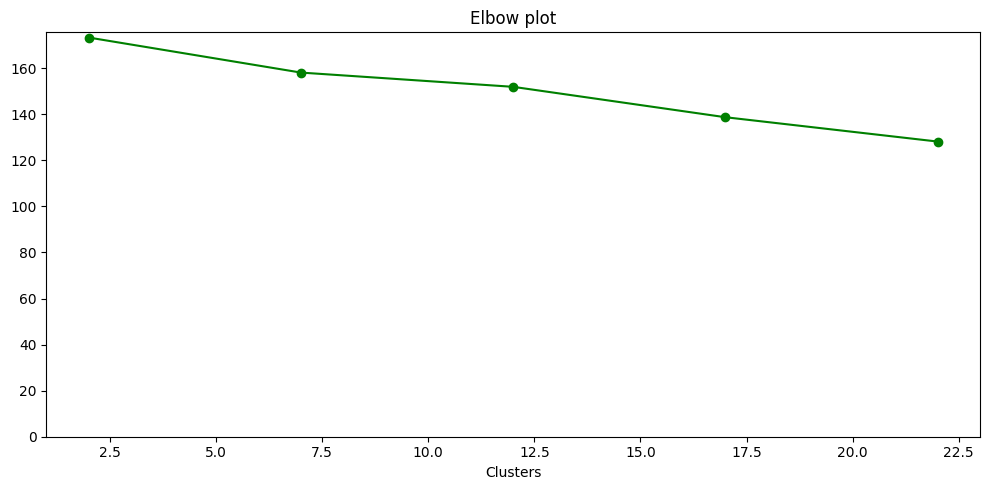

In [39]:
def compute_wssse(df, max_k):
    """
    Computes the Within Sum of Squared Errors (WSSSE) for a range of k values

    :param df: The DataFrame containing the features to be clustered.
    :param max_k: The maximum number of clusters to evaluate.
    :return: A list of tuples, each containing the number of clusters (k) and WSSSE.
    """
    wssses = []
    for k in range(2, max_k + 1, 5):
        kmeans = KMeans(distanceMeasure='cosine', featuresCol='features', k=k, predictionCol='prediction_3')
        model = kmeans.fit(df)      
        wssse = model.summary.trainingCost        
        wssses.append((k, wssse))
    
    return wssses

eval = compute_wssse(classified_df, max_k)

ks, wssses = zip(*eval)

plt.figure(figsize=(10, 5))

plt.plot(ks, wssses, 'go-', label='WSSSE')
plt.xlabel('Clusters')
plt.title('Elbow plot')
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

Now we can set k

In [40]:
K = 10

In [41]:
# K-Means 
kmeans = KMeans(featuresCol='features', k=K, predictionCol='predictions_4')
model = kmeans.fit(classified_df)
final_preds = model.transform(classified_df)

#### 3.2.3 *Inspecting the Clusters*

We can visually inspect the clusters:
- By printing the 10 top words. 
- By printing the content of on document (a section) of each cluster.
- By plotting at a 2-D projected view.

In [42]:
# Print the top words for each cluster
centroids = model.clusterCenters()

vocab = pipeline_model.stages[2].vocabulary

top_words_per_cluster = []

for i, centroid in enumerate(centroids):
    top_indices = np.argsort(centroid)[::-1][:10]  # Get indices of top 10 values
    top_words = [vocab[j] for j in top_indices]
    top_words_per_cluster.append((i, top_words))

for i, words in top_words_per_cluster:
    print(f"Cluster {i}: {', '.join(words)}")

Cluster 0: , |>, >, -, new, use, article, one, like, time
Cluster 1: us, time, believe, system, john, tell, (the, drive, course,, trying
Cluster 2: version, |>, ., believe, previous, computer, known, whole, really, put
Cluster 3: free, chip, top, mac, fbi, religion, name, time, man, require
Cluster 4: go, post, up., make, means, wrote:, available, human, protect, death
Cluster 5: said, assume, world, +, provide, still, subject, sure, mark, love
Cluster 6: read, , bill, it., also, |, go, nothing, even, israeli
Cluster 7: 2, better, scsi, well,, -, include, couple, report, continue, religion
Cluster 8: left, 2, lines, several, saw, games, good, means, field, available
Cluster 9: , come, change, --, |, like, wrote:, things, make, even


In [43]:
# For analysis of results
pd_df = final_preds.toPandas()

# First document for each cluster (ad random)
pd.options.display.max_colwidth = 150

pd_df2 = pd_df[['content', 'predictions_4']].groupby('predictions_4').first()
pd_df2.head(10)

,content
predictions_4,
0,"Is outsourcing the best strategy? Cheltenham human resources (insurance, recruitment etc); marketing; information and IT systems; and delivery.\n..."
1,Discover how a relationship-focused email strategy can help you draw in new customers and retain old ones.\nJoin my growing email community and be...
2,Chapelton Community Masterplan | New Build Houses for sale Aberdeen\nThe Chapelton masterplan is inspired by the vibrant urban settlements of nort...
3,The Purpose of Business & Enterprise - GCSE - Interactive Video & Teaching Resources\nTest students' understanding with a multiple-choice quiz on ...
4,Occupational health and safety - ESG Topics - BII Toolkit\nThis page is designed to help fund managers quickly familiarise themselves with occupat...
5,CSR exhibition service creates purpose... - CSR Exhibition Case Studies\nSee how our clients have increased engagement through our CSR Event Exhib...
6,"ESG Reporting Software, Sustainability Reporting Tool\nA One-Stop ESG Reporting Tool For Modern Businesses\nConsolidate mission-critical data, and..."
7,Wiltshire Wildlife Community Energy's free ‘solar powered’ energy advice service shortlisted for national award - The Business Magazine\nWiltshire...
8,"As an experienced and responsible renewables expert both Renewable Connections, and parent company Armstrong Capital Management is committed to de..."


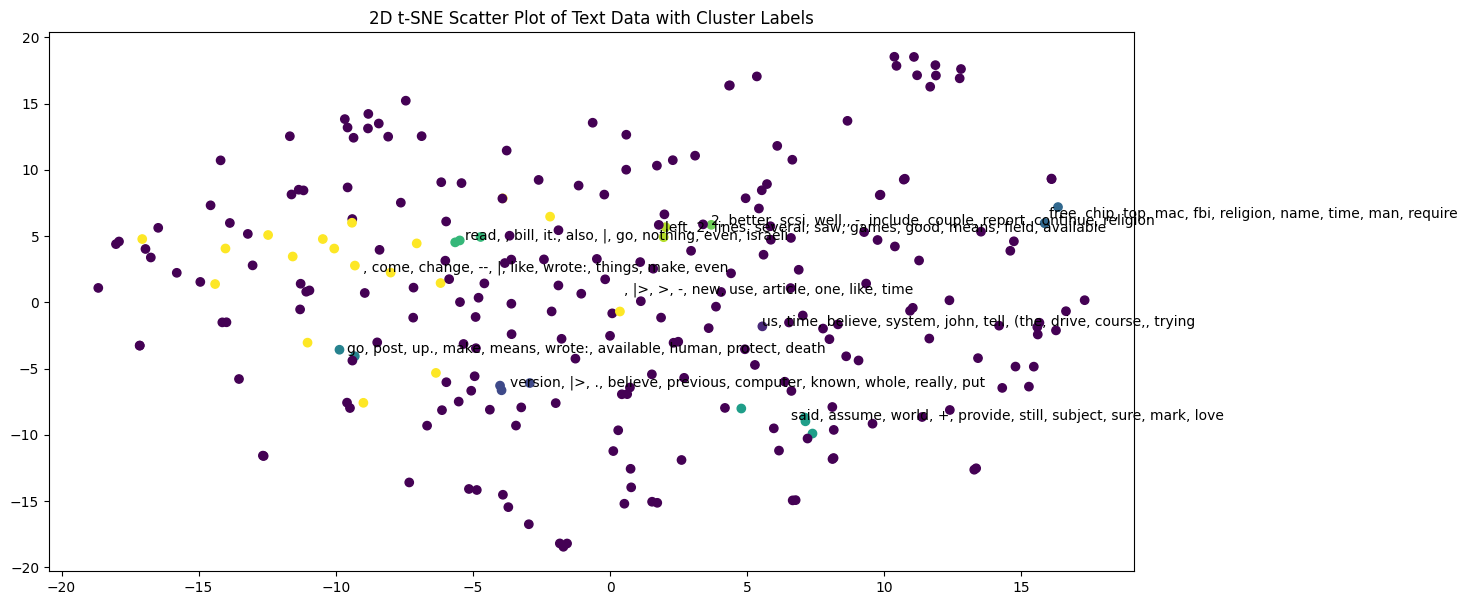

In [44]:
tsne = TSNE(n_components=2, init='random', learning_rate='auto', metric='cosine', square_distances=True)
reduced_tsne = tsne.fit_transform(np.array([vec.toArray() for vec in pd_df.features]))

plt.figure(figsize=(14, 7))
plt.scatter(reduced_tsne[:, 0], reduced_tsne[:, 1], c=pd_df['predictions_4'])

# Recalculate cluster means manually
cluster_centers_tsne = []
for cluster_id in np.unique(pd_df.predictions_4):
    cluster_points = reduced_tsne[pd_df.predictions_4 == cluster_id]
    cluster_center = np.mean(cluster_points, axis=0)
    cluster_centers_tsne.append(cluster_center)

# Annotate the centers with the top words
for i, (center, words) in enumerate(zip(cluster_centers_tsne, top_words_per_cluster)):
    # For a larger k, reduce words
    # if i % 2 == 0:    
    plt.text(center[0], center[1], ', '.join(words[1]))

plt.title('2D t-SNE Scatter Plot of Text Data with Cluster Labels')
plt.show()

#### 3.2.3 Topic Modelling using LDA

For different approach to understanding document similarity, we here implement Latent Dirichlet allocation (LDA). While k-Means groups documents based on their proximity in a feature space, topic modelling represents each document as a mixture of topics. Each topic, in turn, is a probability distribution over words. 

This method captures the underlying themes or concepts across the collection, allowing each document to belong to multiple topics, unlike clustering, where each document belongs to only one cluster.

In [54]:
lda = LDA(k=10, maxIter=10)
model = lda.fit(classified_df)

# The fit of the model (higher is better)
ll = model.logLikelihood(classified_df)

print("The log likelihood:", ll)

The log likelihood: -605610.4675484259


In [55]:
# Perplexity measures prediction accuracy (lower is better)

lp = model.logPerplexity(classified_df)
print("The perplexity:", lp)

The perplexity: 6.881102183055595


In [71]:
# The topics by their top-weighted terms
topics = model.describeTopics(3)
topics.show(truncate=False)

+-----+---------------+------------------------------------------------------------------+
|topic|termIndices    |termWeights                                                       |
+-----+---------------+------------------------------------------------------------------+
|0    |[246, 25, 28]  |[0.018775811823428985, 0.016554229795851805, 0.016136358627127048]|
|1    |[40, 56, 556]  |[0.018670206567483773, 0.010369975775123231, 0.008941669552921735]|
|2    |[453, 551, 408]|[0.00616538408748983, 0.0027288653979991927, 0.00259594654563252] |
|3    |[0, 20, 76]    |[0.014565932332988045, 0.008761859373673212, 0.008709282872369653]|
|4    |[6, 140, 179]  |[0.027987484830189067, 0.009756464883460679, 0.00936306972669889] |
|5    |[912, 247, 805]|[0.011590188934967967, 0.010265331833928824, 0.008509572158027414]|
|6    |[30, 3, 7]     |[0.014661323178181977, 0.012299248652398708, 0.009487589677983898]|
|7    |[708, 747, 159]|[0.011677939505911419, 0.010225889641578507, 0.006758679201829217]|

In [69]:
# Shows the words
transformed = model.transform(classified_df)

transformed.select(['topicDistribution','words']).take(10)

[Row(topicDistribution=DenseVector([0.0531, 0.0006, 0.0006, 0.2705, 0.2728, 0.0634, 0.0007, 0.0448, 0.2929, 0.0006]), words=['is', 'outsourcing', 'the', 'best', 'strategy?', 'cheltenham', '', 'human', 'resources', '(insurance,', 'recruitment', 'etc);', 'marketing;', 'information', 'and', 'it', 'systems;', 'and', 'delivery.', 'management', 'is', 'free', 'to', 'concentrate', 'on', 'the', 'core', 'business', 'the', 'use', 'of', 'resources,', 'including', 'human', 'resources,', 'is', 'streamlined', 'and', 'more', 'focused', 'cost', 'savings', 'are', 'achieved', 'through', 'economies', 'of', 'scale', 'budgeting', 'costs', 'becomes', 'more', 'reliable', 'in', 'these', 'areas', 'because', 'they', 'are', 'tied', 'into', 'contractual', 'agreements.', 'your', 'customers', 'do', 'not', 'draw', 'a', 'distinction', 'between', 'the', 'core', 'services', 'that', 'you', 'provide', 'and', 'the', 'outsourced', 'services', 'supplied', 'by', 'others,', 'so', 'any', 'shortcomings', 'on', 'the', 'part', 'of

In [27]:
spark.stop(), sc.stop()

(None, None)